In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

wandb_results_path = "wandb_results_temp.csv"
df = pd.read_csv(wandb_results_path)

df.dropna(axis=1, how='all', inplace=True)
df.drop(columns=['State', 'Notes', 'Created', 'Runtime', 'Sweep'], inplace=True)
df.sort_values(by='best_val_inv_mse', inplace=True)
df = df.head(10)
df.head(5)

,Name,batch_size,d_model,dropout_p_dec,dropout_p_enc,epochs,extra_pass_prob,gradient_clip_norm,lambda2,learning_rate,...,nhead,num_layers,weight_decay,best_val_inv_mse,composite_train_loss,epoch,train_fwd_mse,train_inv_mse,val_fwd_mse,val_inv_mse
0,winter-sweep-192,16,128,0.0,0.0,3001,0.244206,3,0.015813,0.000478,...,8,4,0.000035,0.001941,-3.120096,2999,0.000498,0.002185,0.002033,0.002567
1,sunny-sweep-145,16,256,0.0,0.1,3001,0.244331,3,0.099547,0.000239,...,8,4,0.000005,0.001982,-3.060917,2999,0.000509,0.002057,0.001607,0.002447
2,fluent-sweep-126,16,256,0.0,0.2,3001,0.145563,3,0.095340,0.000792,...,8,4,0.000038,0.002054,-3.427004,2999,0.002229,0.002284,0.004103,0.002952
3,gentle-sweep-241,16,256,0.0,0.1,3001,0.113802,7,0.029645,0.000494,...,8,4,0.000002,0.002060,-3.161469,2999,0.001422,0.002096,0.003076,0.002632
4,treasured-sweep-161,16,128,0.0,0.1,3001,0.183931,3,0.058816,0.000698,...,8,4,0.000008,0.002064,-3.084104,2999,0.001628,0.002399,0.003736,0.003618


In [2]:
df['d_model'].value_counts(normalize=True)

d_model
256    0.6
128    0.4
Name: proportion, dtype: float64

In [3]:
df['dropout_p_enc'].value_counts(normalize=True)

dropout_p_enc
0.1    0.6
0.0    0.2
0.2    0.2
Name: proportion, dtype: float64

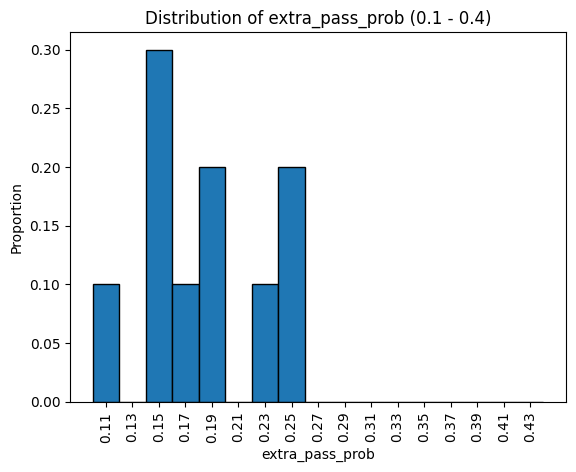

In [15]:
extra_pass_prob_data = df['extra_pass_prob']
bins = np.arange(0.1, 0.45, 0.02) 

plt.hist(extra_pass_prob_data, bins=bins, 
         weights=np.ones(len(extra_pass_prob_data)) / len(extra_pass_prob_data),
         edgecolor='black')

# Calculate and set the centered ticks
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, [f'{val:.2f}' for val in bin_centers], rotation=90)

plt.xlabel('extra_pass_prob')
plt.ylabel('Proportion')
plt.title('Distribution of extra_pass_prob (0.1 - 0.4)')
plt.show()

In [17]:
df['extra_pass_prob'].value_counts(normalize=True, bins=5)

(0.14, 0.166]     0.4
(0.218, 0.244]    0.3
(0.166, 0.192]    0.2
(0.113, 0.14]     0.1
(0.192, 0.218]    0.0
Name: proportion, dtype: float64

In [5]:
df['gradient_clip_norm'].value_counts(normalize=True)

gradient_clip_norm
3    0.7
7    0.2
5    0.1
Name: proportion, dtype: float64

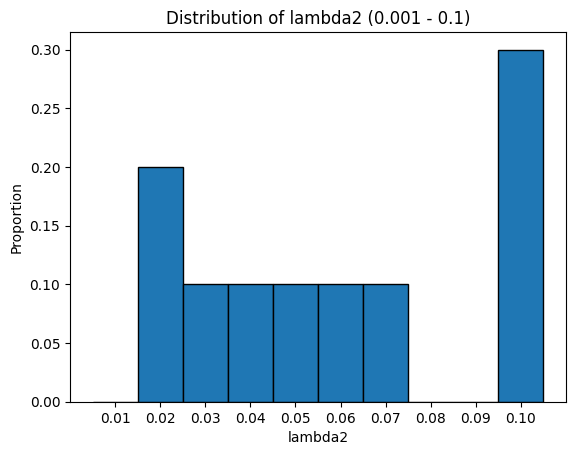

In [6]:
lambda2_data = df['lambda2']
bins = np.arange(0.001, 0.11, 0.01) 

plt.hist(lambda2_data, bins=bins, 
         weights=np.ones(len(lambda2_data)) / len(lambda2_data),
         edgecolor='black')

# Calculate and set the centered ticks
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, [f'{val:.2f}' for val in bin_centers])

plt.xlabel('lambda2')
plt.ylabel('Proportion')
plt.title('Distribution of lambda2 (0.001 - 0.1)')
plt.show()

In [7]:
df['lambda2'].value_counts(normalize=True, bins=10)

(0.0912, 0.0995]                  0.3
(0.014699999999999998, 0.0242]    0.2
(0.0577, 0.0661]                  0.2
(0.0242, 0.0326]                  0.1
(0.0409, 0.0493]                  0.1
(0.0326, 0.0409]                  0.1
(0.0493, 0.0577]                  0.0
(0.0661, 0.0744]                  0.0
(0.0744, 0.0828]                  0.0
(0.0828, 0.0912]                  0.0
Name: proportion, dtype: float64

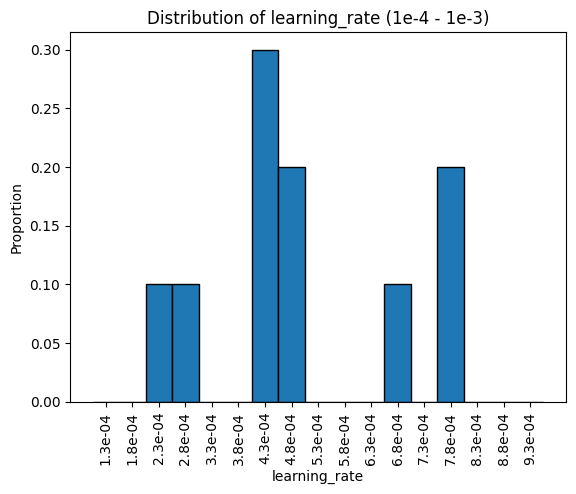

In [18]:
learning_rate_data = df['learning_rate']
bins = np.arange(1e-4, 1e-3, 5e-5) 

plt.hist(learning_rate_data, bins=bins, 
         weights=np.ones(len(learning_rate_data)) / len(learning_rate_data),
         edgecolor='black')

# Calculate and set the centered ticks
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, [f'{val:.1e}' for val in bin_centers], rotation=90)

plt.xlabel('learning_rate')
plt.ylabel('Proportion')
plt.title('Distribution of learning_rate (1e-4 - 1e-3)')
plt.show()

In [9]:
df.columns

Index(['Name', 'batch_size', 'd_model', 'dropout_p_dec', 'dropout_p_enc',
       'epochs', 'extra_pass_prob', 'gradient_clip_norm', 'lambda2',
       'learning_rate', 'mask_drop_prob_max', 'nhead', 'num_layers',
       'weight_decay', 'best_val_inv_mse', 'composite_train_loss', 'epoch',
       'train_fwd_mse', 'train_inv_mse', 'val_fwd_mse', 'val_inv_mse'],
      dtype='object')

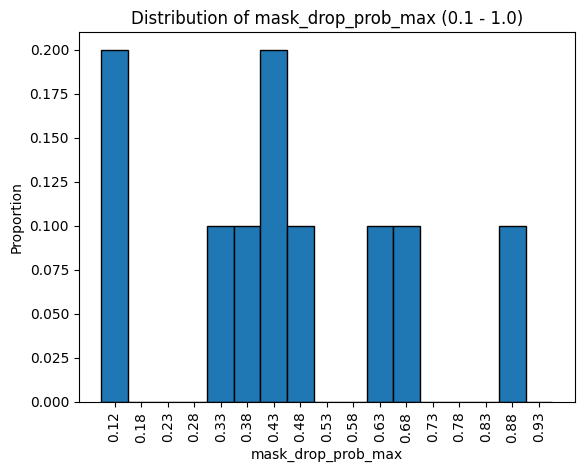

In [10]:
mask_drop_prob_max_data = df['mask_drop_prob_max']
bins = np.arange(0.1, 1, 0.05) 

plt.hist(mask_drop_prob_max_data, bins=bins, 
         weights=np.ones(len(mask_drop_prob_max_data)) / len(mask_drop_prob_max_data),
         edgecolor='black')

# Calculate and set the centered ticks
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, [f'{val:.2f}' for val in bin_centers], rotation=90)

plt.xlabel('mask_drop_prob_max')
plt.ylabel('Proportion')
plt.title('Distribution of mask_drop_prob_max (0.1 - 1.0)')
plt.show()

In [11]:
df['nhead'].value_counts(normalize=True)

nhead
8    1.0
Name: proportion, dtype: float64

In [12]:
df['num_layers'].value_counts(normalize=True)

num_layers
4    1.0
Name: proportion, dtype: float64

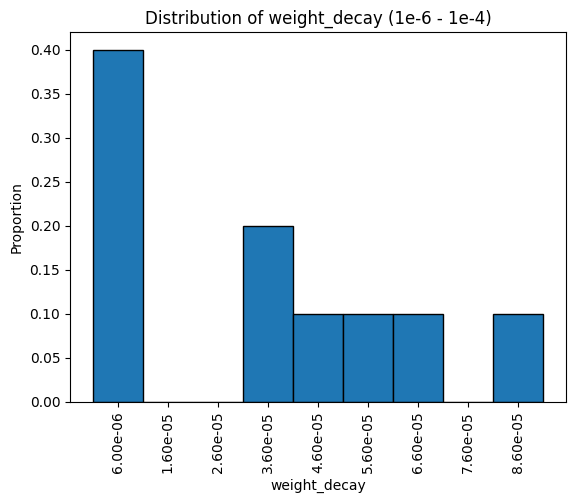

In [13]:
weight_decay_data = df['weight_decay']
bins = np.arange(1e-6, 1e-4, 1e-5) 

plt.hist(weight_decay_data, bins=bins, 
         weights=np.ones(len(weight_decay_data)) / len(weight_decay_data),
         edgecolor='black')

# Calculate and set the centered ticks
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, [f'{val:.2e}' for val in bin_centers], rotation=90)

plt.xlabel('weight_decay')
plt.ylabel('Proportion')
plt.title('Distribution of weight_decay (1e-6 - 1e-4)')
plt.show()

In [20]:
df['weight_decay'].value_counts(normalize=True, bins=5)

(-0.0009983400000000001, 1.79e-05]    0.4
(3.4e-05, 5.01e-05]                   0.3
(5.01e-05, 6.62e-05]                  0.2
(6.62e-05, 8.24e-05]                  0.1
(1.79e-05, 3.4e-05]                   0.0
Name: proportion, dtype: float64